# RadHarmony: Writing Your Own Dataset

RadHarmony ships around 30 datasets, but you will often have one it does not.
This notebook shows how to add your own: a small **harmonizer** that turns your
raw files into RadHarmony's canonical table, plus a thin **dataset** class that
wires it in and registers a name. Everything downstream (transforms, caching,
patient-level splitting, DataLoaders) is then inherited, just like the built-in
datasets.

The result is a standard PyTorch dataset you can hand straight to a `DataLoader`.

## Setup

Suppose we come across another copy of the **Montgomery County chest X-ray set**
(the same one used in the main notebook) and want to add it to RadHarmony. We use
it here as a small, familiar example.

In [1]:
import os 
import sys

sys.path.insert(0, os.path.abspath(".."))

from basepaths import *

In [2]:
# base_image_dir: the last common folder that contains every image. Each row's
# image_path is resolved relative to it (same path as the main hands-on notebook).

# MONTGOMERY_DIR = "/mnt/efs/cxr/Montgomery-CXR/MontgomerySet/CXR_png/"

## The two classes

Adding a dataset takes two small classes:

- a **harmonizer** (subclassing `BaseHarmonizer`) that maps your raw metadata
  into RadHarmony's canonical columns (`patient_id`, `study_id`, `image_path`,
  and the labels);
- a **dataset** (subclassing `BaseRadiologicalDataset`) that points at the
  harmonizer and registers a name, so it can be looked up and used like any
  built-in.

The base class then provides transforms, caching, patient-level splitting, and
k-fold for free. The steps below fill in the specifics, wrapping this Montgomery
data using a small metadata CSV that ships with this tutorial.

**Step 1: inspect the raw dataset.** Before writing any code, look at what you
have and decide how it maps onto the canonical columns. This Montgomery variant ships a folder
of PNGs plus a metadata CSV with one row per image; its `pid` / `fname` / `tb`
columns give the patient ID, the image file path, and the TB label the harmonizer will
need.

In [3]:
import pandas as pd
from radharmony.harmonizer.base import BaseHarmonizer

# Your dataset already comes with a metadata CSV. This one ships with the
# tutorial (data/montgomery_toy.csv): one row per image, columns pid/fname/tb.
index_csv = f"{SESSION_DATA}montgomery_toy.csv"
print(f"metadata CSV path: {index_csv}")
print("Raw metadata CSV (what you start with):")
display(pd.read_csv(index_csv).head())

metadata CSV path: /mnt/efs/cxr/session_data/montgomery_toy.csv
Raw metadata CSV (what you start with):


,pid,fname,tb
0,1,MCUCXR_0001_0.png,0
1,2,MCUCXR_0002_0.png,0
2,3,MCUCXR_0003_0.png,0
3,4,MCUCXR_0004_0.png,0
4,5,MCUCXR_0005_0.png,0


**Step 2: the harmonizer.** Four small methods encode that mapping: three fill the always-present columns (`patient_id`, `study_id`, `image_path`), and `_build_labels()` produces the label named in `LABEL_COLS`. Compare the raw CSV above with the harmonized table it returns:

In [4]:
class MyMontgomeryHarmonizer(BaseHarmonizer):
    LABEL_COLS = ["tuberculosis"]  # which columns are labels to carry into the table

    def __init__(self, csv_path, base_image_dir):
        super().__init__(csv_path=csv_path)
        self.base_image_dir = base_image_dir

    def _build_patient_id(self):
        self.df["patient_id"] = self.df["pid"].astype(str)

    def _build_study_id(self):
        self.df["study_id"] = self.df["pid"].astype(str)  # one study per patient here

    def _build_image_path(self):
        self.df["image_path"] = self.df["fname"].astype(
            str
        )  # relative to base_image_dir

    def _build_labels(self):
        # Produce each column named in LABEL_COLS. Here the raw `tb` column is
        # already 0/1, so we just ensure it is integer-typed; a real dataset
        # might map text like "TB"/"Normal" to 1/0 or merge a separate label CSV.
        self.df["tuberculosis"] = self.df["tb"].astype(int)  # 0 = normal, 1 = TB


# Running the harmonizer produces the canonical table used everywhere else.
my_df = MyMontgomeryHarmonizer(
    csv_path=index_csv, base_image_dir=MONTGOMERY_DIR
).harmonize()
print("\nHarmonized table (same canonical columns as the built-in datasets):")
display(my_df.head())


Harmonized table (same canonical columns as the built-in datasets):


,patient_id,study_id,image_path,tuberculosis
0,1,1,MCUCXR_0001_0.png,0
1,2,2,MCUCXR_0002_0.png,0
2,3,3,MCUCXR_0003_0.png,0
3,4,4,MCUCXR_0004_0.png,0
4,5,5,MCUCXR_0005_0.png,0


**Step 3: the dataset class.** Three declarations do the work: `LABEL_COLS`, `_HARMONIZER_CLS`, and `_get_harmonized_df`. The base class supplies transforms, caching, patient-level splitting, and k-fold.

In [5]:
from radharmony.dataset import BaseRadiologicalDataset, RadiologyTransform2D
from radharmony.registry import register_dataset, resolve_dataset, list_datasets


class MyMontgomeryDatasetManual(BaseRadiologicalDataset):
    LABEL_COLS = ["tuberculosis"]
    SUPPORTED_OUTPUTS = frozenset({"cls"})
    _HARMONIZER_CLS = MyMontgomeryHarmonizer

    def __init__(self, base_image_dir, index_csv_path, cache_dir=None):
        self._index_csv_path = index_csv_path
        super().__init__(
            base_image_dir=base_image_dir,
            transform=RadiologyTransform2D(
                img_size=224, output_keys={"img", "cls"}
            ).get_transform(),
            cache_dir=cache_dir,
            output_cls=True,
        )

    def _get_harmonized_df(self):
        return MyMontgomeryHarmonizer(
            csv_path=self._index_csv_path, base_image_dir=self.base_image_dir
        ).harmonize()

**Step 4: register and use it.** Registering adds the class to the global registry, so you (or the Gradio app) can look it up by name and use it exactly like a built-in dataset.

In [6]:
# @register_dataset("my_montgomery") is the usual way to register; here we call it
# as a plain function, guarded so re-running the cell does not re-register it.
if "my_montgomery_manual" not in list_datasets():
    register_dataset("my_montgomery_manual")(MyMontgomeryDatasetManual)

# Look it up by name and use it like any built-in class.
MyMontgomeryDataset = resolve_dataset("my_montgomery_manual")
my_ds = MyMontgomeryDataset(base_image_dir=MONTGOMERY_DIR, index_csv_path=index_csv)
print("Registry now includes 'my_montgomery_manual':", "my_montgomery_manual" in list_datasets())
print("Images built from my dataset class:", len(my_ds.get_datasets()))

Registry now includes 'my_montgomery_manual': True
Images built from my dataset class: 138


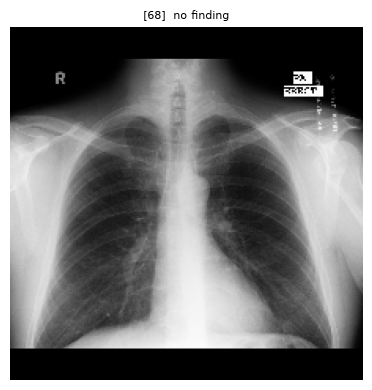

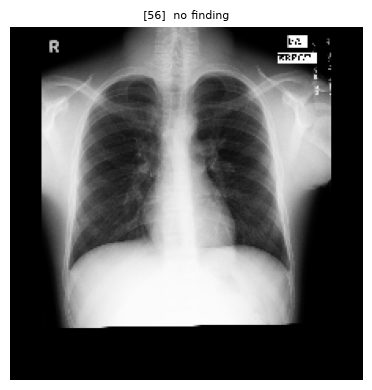

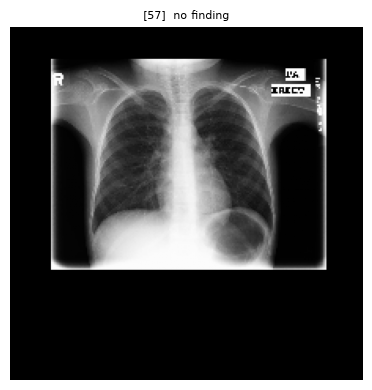

In [7]:
import matplotlib.pyplot as plt

# visualize_samples yields one figure per sample, so build the dataset and
# iterate, displaying (then closing) each figure.
built = my_ds.get_datasets()
for fig in my_ds.visualize_samples(built, n=3):
    display(fig)
    plt.close(fig)

## What you get

`MyMontgomeryDataset` now behaves exactly like a built-in RadHarmony dataset: `get_datasets()`, patient-level splits and k-fold, `DataLoader` batching, `RadiologyTransform2D` augmentation, and image caching, all inherited from the base class. Full documentation: **[f10409.github.io/RadHarmony](https://f10409.github.io/RadHarmony)**.